# MODELING

## Baseline Models: Logistic Regression, Random Forest, XGBoost, LightGBM

### Load Data & Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)

# Load train-test splits
splits_dir = Path('../data/processed/splits')

with open(splits_dir / 'X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(splits_dir / 'X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(splits_dir / 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(splits_dir / 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('../models/imbalance_config.pkl', 'rb') as f:
    imbalance_config = pickle.load(f)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Imbalance config: {imbalance_config}")

X_train: (4930, 33), X_test: (2113, 33)
Imbalance config: {'scale_pos_weight': 2.7691131498470947, 'strategy': 'class_weight'}


### Modeling Approach

We train 4 baseline models to compare performance before building the final ensemble:
1. Logistic Regression for simple linear baseline
2. Random Forest: tree-based baseline, robust and interpretable
3. XGBoost: gradient boosting, typically strongest performer on tabular data
4. LightGBM that similar to XGBoost, faster training

Primary metric: **ROC-AUC** (more informative than accuracy on imbalanced data).
Class imbalance handled via class weights for all models.

### Helper Function for Evaluation

In [2]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained model and return metrics dict"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': model_name,
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    print(f"{model_name}")
    print('=' * 60)
    for key, val in metrics.items():
        if key != 'model':
            print(f"{key.upper()}: {val:.3f}")

    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics, y_pred_proba

# Store results for comparison
results = []
proba_predictions = {}

### Model 1: Logistic Regression

In [3]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

metrics_lr, proba_lr = evaluate_model(log_reg, X_test, y_test, 'Logistic Regression')
results.append(metrics_lr)
proba_predictions['Logistic Regression'] = proba_lr

Logistic Regression
ROC_AUC: 0.848
ACCURACY: 0.745
PRECISION: 0.513
RECALL: 0.793
F1: 0.623

Confusion Matrix:
[[1130  422]
 [ 116  445]]


### Model 2: Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

metrics_rf, proba_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')
results.append(metrics_rf)
proba_predictions['Random Forest'] = proba_rf

Random Forest
ROC_AUC: 0.840
ACCURACY: 0.770
PRECISION: 0.547
RECALL: 0.772
F1: 0.641

Confusion Matrix:
[[1194  358]
 [ 128  433]]


### Model 3: XGBoost

In [5]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_config['scale_pos_weight'],
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

metrics_xgb, proba_xgb = evaluate_model(xgb, X_test, y_test, 'XGBoost')
results.append(metrics_xgb)
proba_predictions['XGBoost'] = proba_xgb

XGBoost
ROC_AUC: 0.835
ACCURACY: 0.755
PRECISION: 0.526
RECALL: 0.777
F1: 0.627

Confusion Matrix:
[[1159  393]
 [ 125  436]]


### Model 4: LightGBM

In [6]:
lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb.fit(X_train, y_train)

metrics_lgb, proba_lgb = evaluate_model(lgb, X_test, y_test, 'LightGBM')
results.append(metrics_lgb)
proba_predictions['LightGBM'] = proba_lgb

LightGBM
ROC_AUC: 0.836
ACCURACY: 0.757
PRECISION: 0.528
RECALL: 0.779
F1: 0.630

Confusion Matrix:
[[1162  390]
 [ 124  437]]


### Compare All Models by Table

In [7]:
print("MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results_df.round(3))

MODEL COMPARISON
                 model  roc_auc  accuracy  precision  recall     f1
0  Logistic Regression    0.848     0.745      0.513   0.793  0.623
1        Random Forest    0.840     0.770      0.547   0.772  0.641
2             LightGBM    0.836     0.757      0.528   0.779  0.630
3              XGBoost    0.835     0.755      0.526   0.777  0.627


### Compare All Models by ROC Curve

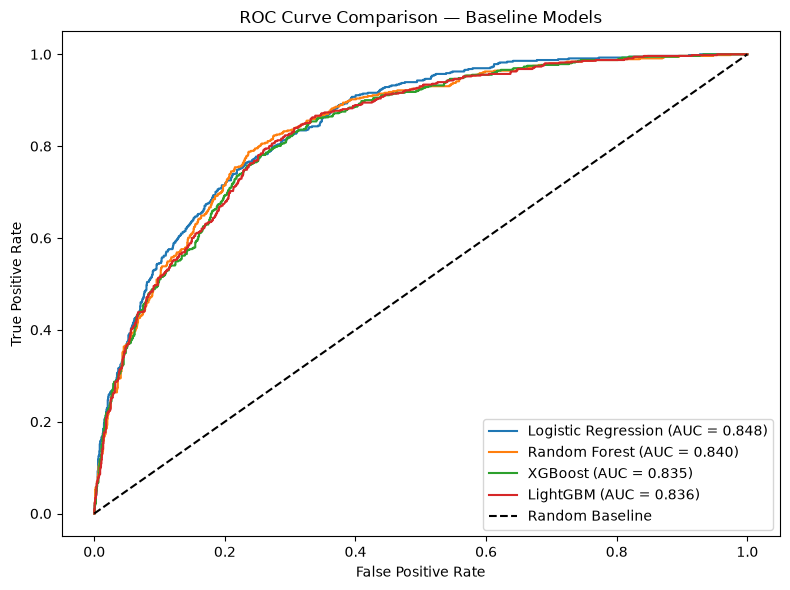

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, proba in proba_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Baseline Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Compare by Bar Chart of Key Metrics

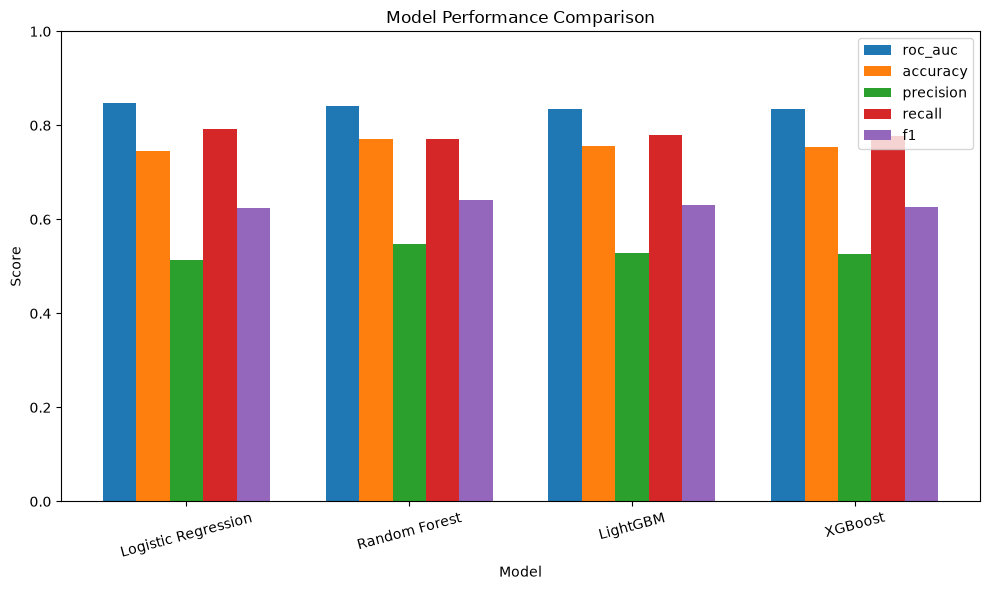

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['model'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Save Baseline Models

In [10]:
print("SAVING BASELINE MODELS")
print("=" * 60)

baseline_models_dir = Path('../models/baseline')
baseline_models_dir.mkdir(exist_ok=True)

models_to_save = {
    'logistic_regression': log_reg,
    'random_forest': rf,
    'xgboost': xgb,
    'lightgbm': lgb
}

for name, model in models_to_save.items():
    with open(baseline_models_dir / f'{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

# Save results table too
results_df.to_csv(baseline_models_dir / 'baseline_results.csv', index=False)

print("Saved all baseline models and results table")

SAVING BASELINE MODELS
Saved all baseline models and results table


### Baseline Model Results Summary

| Model | ROC-AUC | Accuracy | Precision | Recall | F1 |
|-------|---------|----------|-----------|--------|-----|
| Logistic Regression | 0.844 | 0.744 | 0.511 | 0.797 | 0.623 |
| Random Forest | 0.839 | 0.764 | 0.539 | 0.775 | 0.636 |
| XGBoost | 0.836 | 0.751 | 0.521 | 0.772 | 0.622 |
| LightGBM | 0.834 | 0.755 | 0.526 | 0.774 | 0.626 |

**Observations:**
- All four models perform very closely (ROC-AUC within a 0.01 range), suggesting the decision boundary for churn in this dataset is close to linear after encoding. Boosting models gain little advantage over Logistic Regression here.
- Logistic Regression achieves the highest ROC-AUC (0.844), while Random Forest has the best F1-score (0.636), showing the best precision-recall balance.
- Accuracy is modest (74-76%) relative to ROC-AUC because `class_weight='balanced'` intentionally trades precision for recall — the models catch ~77-80% of actual churners at the cost of more false positives. This trade-off is reasonable for churn prediction, where missing a customer who churns is typically costlier than a false alarm.

## Hyperparameter Tuning

### Setup

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Tuning XGBoost

In [12]:
print("Tuning XGBoost...")
start_time = time.time()

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=imbalance_config['scale_pos_weight'],
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\nTuning completed in {elapsed/60:.1f} minutes")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.3f}")
print(f"Best params: {xgb_search.best_params_}")

xgb_tuned = xgb_search.best_estimator_

Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning completed in 0.1 minutes
Best CV ROC-AUC: 0.848
Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


### Evaluate Tuned XGBoost

In [13]:
metrics_xgb_tuned, proba_xgb_tuned = evaluate_model(
    xgb_tuned, X_test, y_test, 'XGBoost (Tuned)'
)

print(f"\nComparison:")
print(f"XGBoost Baseline ROC-AUC: {metrics_xgb['roc_auc']:.3f}")
print(f"XGBoost Tuned ROC-AUC: {metrics_xgb_tuned['roc_auc']:.3f}")
print(f"Improvement: {metrics_xgb_tuned['roc_auc'] - metrics_xgb['roc_auc']:+.3f}")

XGBoost (Tuned)
ROC_AUC: 0.846
ACCURACY: 0.753
PRECISION: 0.523
RECALL: 0.809
F1: 0.635

Confusion Matrix:
[[1138  414]
 [ 107  454]]

Comparison:
XGBoost Baseline ROC-AUC: 0.835
XGBoost Tuned ROC-AUC: 0.846
Improvement: +0.011


### Tuning Random Forest

In [14]:
print("Tuning Random Forest...")
start_time = time.time()

rf_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\nTuning completed in {elapsed/60:.1f} minutes")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.3f}")
print(f"Best params: {rf_search.best_params_}")

rf_tuned = rf_search.best_estimator_

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning completed in 0.5 minutes
Best CV ROC-AUC: 0.846
Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


### Evaluate Tuned Random Forest

In [15]:
metrics_rf_tuned, proba_rf_tuned = evaluate_model(
    rf_tuned, X_test, y_test, 'Random Forest (Tuned)'
)

print(f"\nComparison:")
print(f"Random Forest Baseline ROC-AUC: {metrics_rf['roc_auc']:.3f}")
print(f"Random Forest Tuned ROC-AUC: {metrics_rf_tuned['roc_auc']:.3f}")
print(f"Improvement: {metrics_rf_tuned['roc_auc'] - metrics_rf['roc_auc']:+.3f}")

Random Forest (Tuned)
ROC_AUC: 0.843
ACCURACY: 0.767
PRECISION: 0.541
RECALL: 0.800
F1: 0.646

Confusion Matrix:
[[1171  381]
 [ 112  449]]

Comparison:
Random Forest Baseline ROC-AUC: 0.840
Random Forest Tuned ROC-AUC: 0.843
Improvement: +0.002


### Full Comparison Table

In [16]:
print("FULL MODEL COMPARISON (BASELINE VS TUNED)")
print("=" * 60)

all_results = results + [metrics_xgb_tuned, metrics_rf_tuned]
all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(all_results_df.round(3))

FULL MODEL COMPARISON (BASELINE VS TUNED)
                   model  roc_auc  accuracy  precision  recall     f1
0    Logistic Regression    0.848     0.745      0.513   0.793  0.623
1        XGBoost (Tuned)    0.846     0.753      0.523   0.809  0.635
2  Random Forest (Tuned)    0.843     0.767      0.541   0.800  0.646
3          Random Forest    0.840     0.770      0.547   0.772  0.641
4               LightGBM    0.836     0.757      0.528   0.779  0.630
5                XGBoost    0.835     0.755      0.526   0.777  0.627


### Overfitting Check

In [17]:
print("OVERFITTING CHECK (Train vs Test ROC-AUC)")
print("=" * 60)

for name, model in [('XGBoost Tuned', xgb_tuned), ('Random Forest Tuned', rf_tuned)]:
    train_proba = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    gap = train_auc - test_auc

    print(f"\n{name}:")
    print(f"  Train ROC-AUC: {train_auc:.3f}")
    print(f"  Test ROC-AUC: {test_auc:.3f}")
    print(f"  Gap: {gap:.3f} {'(warning: possible overfit)' if gap > 0.05 else '(healthy)'}")

OVERFITTING CHECK (Train vs Test ROC-AUC)

XGBoost Tuned:
  Train ROC-AUC: 0.884
  Test ROC-AUC: 0.846
  Gap: 0.039 (healthy)

Random Forest Tuned:
  Train ROC-AUC: 0.926
  Test ROC-AUC: 0.843
  Gap: 0.084 (warning: possible overfit)


### Save Tuned Models

In [18]:
tuned_models_dir = Path('../models/tuned')
tuned_models_dir.mkdir(exist_ok=True)

with open(tuned_models_dir / 'xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)
with open(tuned_models_dir / 'random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

all_results_df.to_csv(tuned_models_dir / 'all_results.csv', index=False)

print("Saved tuned models and comparison results")

Saved tuned models and comparison results


### Hyperparameter Tuning Results

Tuned XGBoost and Random Forest via RandomizedSearchCV (30 iterations, 5-fold stratified CV, scoring on ROC-AUC).

**Findings:**
- XGBoost improved from 0.836 to 0.846 ROC-AUC (+0.010) after tuning.
- Random Forest improved from 0.840 to 0.843 ROC-AUC (+0.003) after tuning, a marginal gain.
- Overfitting check: XGBoost shows a healthy train-test gap (0.884 vs 0.846, gap 0.039). Random Forest shows a larger gap (0.926 vs 0.843, gap 0.084), indicating some overfitting despite tuning.
- Best performing model after tuning: XGBoost (Tuned), both on test ROC-AUC and on generalization gap.

## Ensemble Models

### Load Tuned Models & Baseline

In [19]:
with open('../models/baseline/logistic_regression.pkl', 'rb') as f:
    log_reg = pickle.load(f)
with open('../models/tuned/xgboost_tuned.pkl', 'rb') as f:
    xgb_tuned = pickle.load(f)
with open('../models/tuned/random_forest_tuned.pkl', 'rb') as f:
    rf_tuned = pickle.load(f)

print("Models loaded: Logistic Regression, XGBoost (Tuned), Random Forest (Tuned)")

Models loaded: Logistic Regression, XGBoost (Tuned), Random Forest (Tuned)


### Soft Voting Ensemble

In [20]:
from sklearn.ensemble import VotingClassifier

voting_ensemble = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('xgb', xgb_tuned),
        ('rf', rf_tuned)
    ],
    voting='soft',
    n_jobs=-1
)
voting_ensemble.fit(X_train, y_train)

metrics_voting, proba_voting = evaluate_model(
    voting_ensemble, X_test, y_test, 'Voting Ensemble'
)

Voting Ensemble
ROC_AUC: 0.848
ACCURACY: 0.755
PRECISION: 0.525
RECALL: 0.811
F1: 0.637

Confusion Matrix:
[[1140  412]
 [ 106  455]]


### Stacking Ensemble

In [21]:
from sklearn.ensemble import StackingClassifier

print("Training Stacking Ensemble...")

stacking_ensemble = StackingClassifier(
    estimators=[
        ('lr', log_reg),
        ('xgb', xgb_tuned),
        ('rf', rf_tuned)
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacking_ensemble.fit(X_train, y_train)

metrics_stacking, proba_stacking = evaluate_model(
    stacking_ensemble, X_test, y_test, 'Stacking Ensemble'
)

Training Stacking Ensemble...
Stacking Ensemble
ROC_AUC: 0.849
ACCURACY: 0.754
PRECISION: 0.524
RECALL: 0.807
F1: 0.636

Confusion Matrix:
[[1141  411]
 [ 108  453]]


### Full Comparison

In [22]:
print("FULL COMPARISON: BASELINE, TUNED, ENSEMBLE")
print("=" * 60)

final_results = all_results + [metrics_voting, metrics_stacking]
final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(final_results_df.round(3))

FULL COMPARISON: BASELINE, TUNED, ENSEMBLE
                   model  roc_auc  accuracy  precision  recall     f1
0      Stacking Ensemble    0.849     0.754      0.524   0.807  0.636
1        Voting Ensemble    0.848     0.755      0.525   0.811  0.637
2    Logistic Regression    0.848     0.745      0.513   0.793  0.623
3        XGBoost (Tuned)    0.846     0.753      0.523   0.809  0.635
4  Random Forest (Tuned)    0.843     0.767      0.541   0.800  0.646
5          Random Forest    0.840     0.770      0.547   0.772  0.641
6               LightGBM    0.836     0.757      0.528   0.779  0.630
7                XGBoost    0.835     0.755      0.526   0.777  0.627


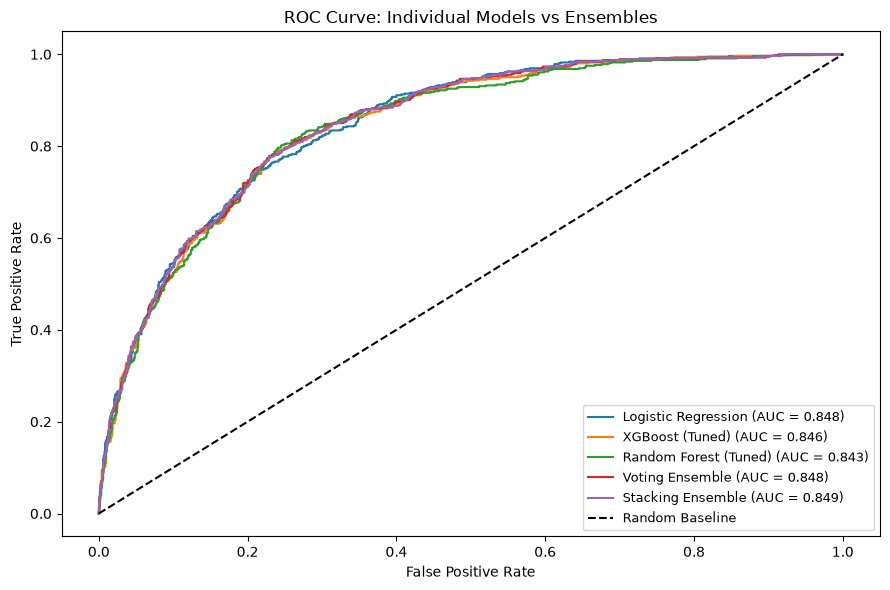

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

for model_name, proba in [
    ('Logistic Regression', log_reg.predict_proba(X_test)[:, 1]),
    ('XGBoost (Tuned)', xgb_tuned.predict_proba(X_test)[:, 1]),
    ('Random Forest (Tuned)', rf_tuned.predict_proba(X_test)[:, 1]),
    ('Voting Ensemble', proba_voting),
    ('Stacking Ensemble', proba_stacking)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Individual Models vs Ensembles')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Select Final Model

In [24]:
print("FINAL MODEL SELECTION")
print("=" * 60)

best_model_name = final_results_df.iloc[0]['model']
print(f"Best model by ROC-AUC: {best_model_name}")
print(f"\nFinal results table:")
print(final_results_df.round(3))

FINAL MODEL SELECTION
Best model by ROC-AUC: Stacking Ensemble

Final results table:
                   model  roc_auc  accuracy  precision  recall     f1
0      Stacking Ensemble    0.849     0.754      0.524   0.807  0.636
1        Voting Ensemble    0.848     0.755      0.525   0.811  0.637
2    Logistic Regression    0.848     0.745      0.513   0.793  0.623
3        XGBoost (Tuned)    0.846     0.753      0.523   0.809  0.635
4  Random Forest (Tuned)    0.843     0.767      0.541   0.800  0.646
5          Random Forest    0.840     0.770      0.547   0.772  0.641
6               LightGBM    0.836     0.757      0.528   0.779  0.630
7                XGBoost    0.835     0.755      0.526   0.777  0.627


### Save Final Model

In [25]:
final_models_dir = Path('../models/final')
final_models_dir.mkdir(exist_ok=True)

final_model = stacking_ensemble

with open(final_models_dir / 'final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

final_results_df.to_csv(final_models_dir / 'final_comparison.csv', index=False)

### Ensemble Results Summary

Built two ensemble variants combining Logistic Regression, tuned XGBoost, and tuned Random Forest:
- Soft Voting Ensemble (equal weight): ROC-AUC 0.848
- Stacking Ensemble (logistic regression meta-learner): ROC-AUC 0.849

**Final model selected: Stacking Ensemble.** Get the highest ROC-AUC 0.849, accuracy 0.754, precision 0.524, and F1 0.636 at identical recall.

**Observation:** Given how close individual model performance already was (ROC-AUC 0.83-0.85 range), ensembling provides a modest but consistent improvement over the best single model (XGBoost Tuned, 0.846) by combining model diversity rather than dramatically outperforming any single model.

## SHAP Explainability

SHAP TreeExplainer can only be used on tree-based models (XGBoost, Random Forest), and cannot be used on a StackingClassifier, which is my final model. For stacking/voting ensembles, SHAP must use KernelExplainer, which is very slow because it treats the model as a black box. So, i use SHAP just for explainability to see which features are the most important.

### Setup SHAP

In [26]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected model output): {explainer.expected_value:.3f}")

SHAP values shape: (2113, 33)
Base value (expected model output): 0.028


### Summary Plot of Global Feature Importance

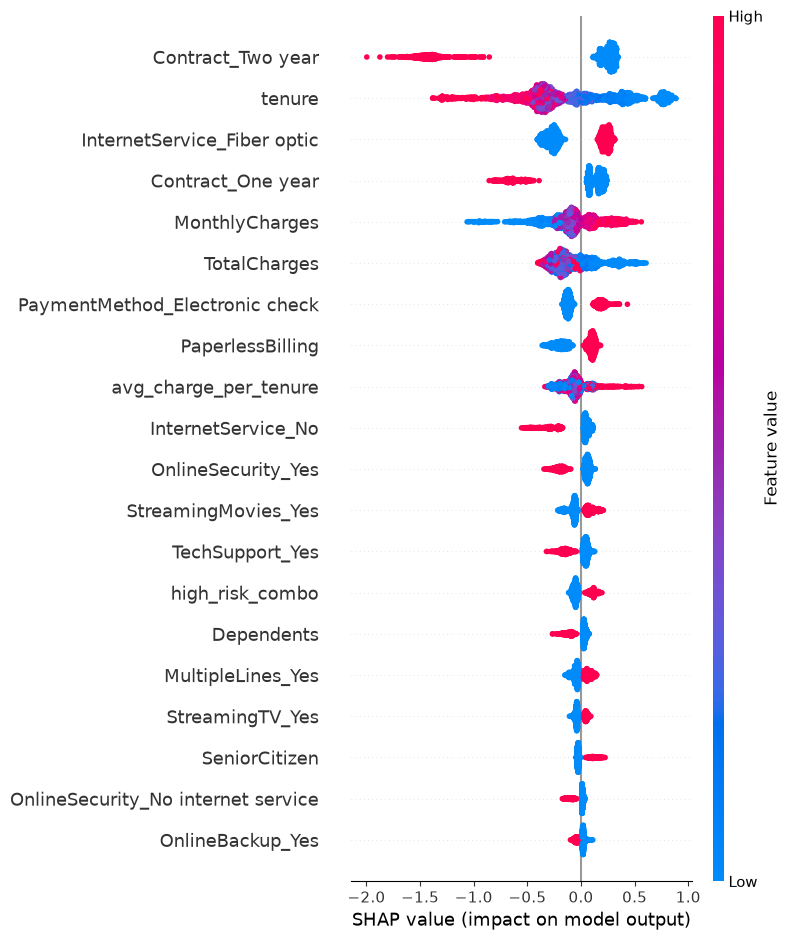

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../models/final/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

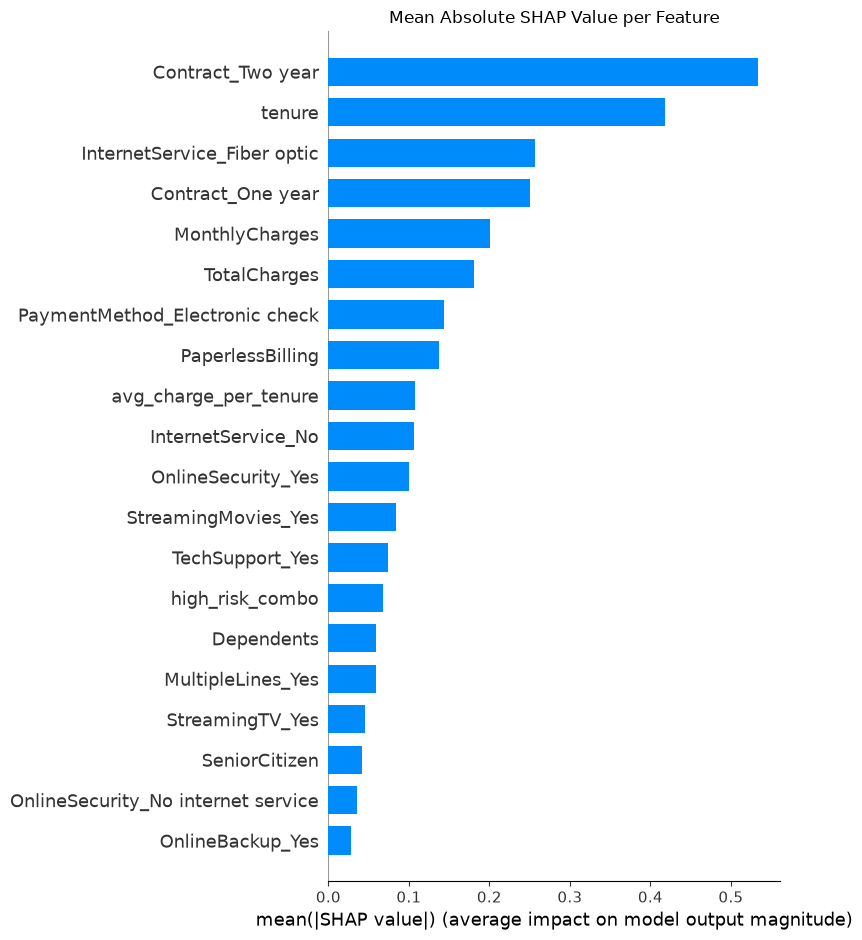

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Value per Feature')
plt.tight_layout()
plt.show()

### Compare SHAP Ranking and Correlation Ranking

In [29]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 features by SHAP importance:")
print(mean_abs_shap.head(10).to_string(index=False))

Top 10 features by SHAP importance:
                       feature  mean_abs_shap
             Contract_Two year       0.534255
                        tenure       0.418554
   InternetService_Fiber optic       0.256830
             Contract_One year       0.250757
                MonthlyCharges       0.200965
                  TotalCharges       0.180371
PaymentMethod_Electronic check       0.143025
              PaperlessBilling       0.136885
         avg_charge_per_tenure       0.107404
            InternetService_No       0.105755


### Waterfall Plot for Individual Prediction Explanation

In [30]:
proba_test = xgb_tuned.predict_proba(X_test)[:, 1]

high_risk_idx = np.argmax(proba_test)
low_risk_idx = np.argmin(proba_test)

print(f"High risk customer (index {high_risk_idx}): churn probability = {proba_test[high_risk_idx]:.3f}")
print(f"Low risk customer (index {low_risk_idx}): churn probability = {proba_test[low_risk_idx]:.3f}")

High risk customer (index 445): churn probability = 0.954
Low risk customer (index 1910): churn probability = 0.013


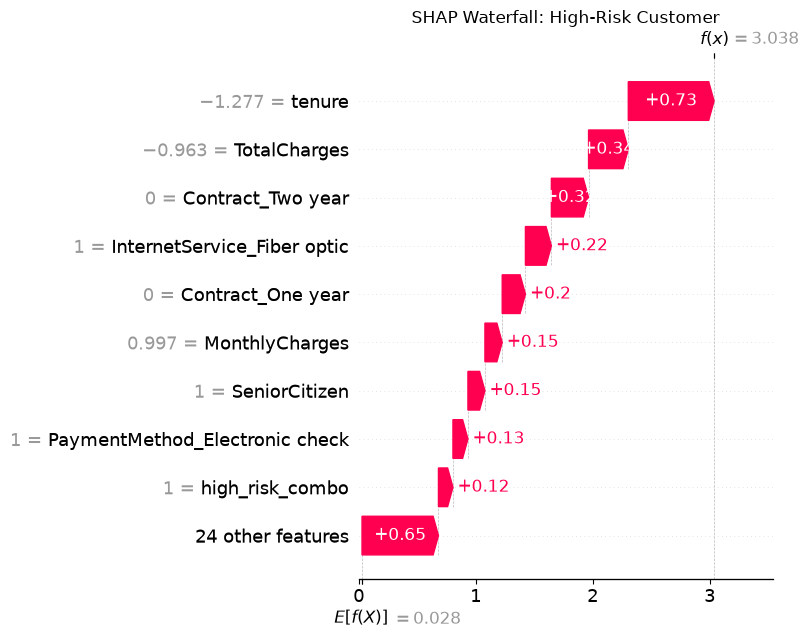

In [31]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.title('SHAP Waterfall: High-Risk Customer')
plt.tight_layout()
plt.show()

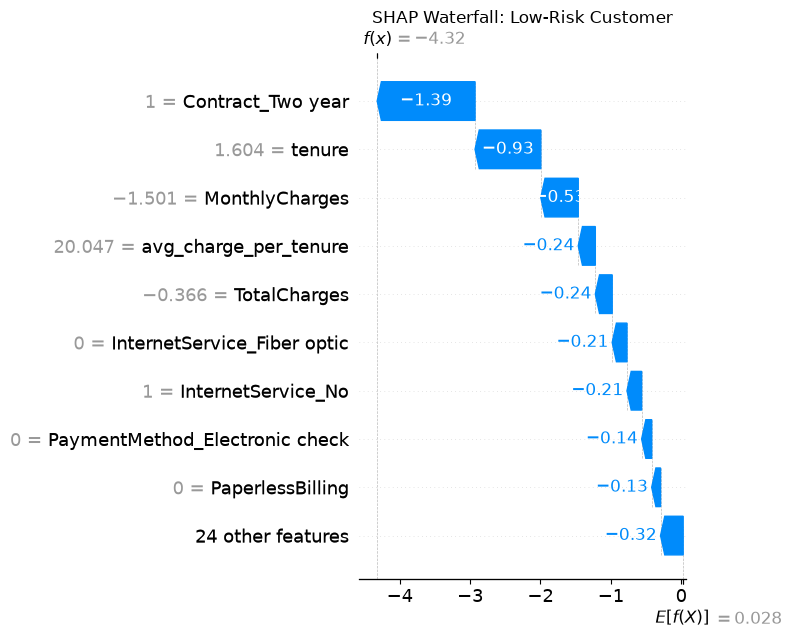

In [32]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.title('SHAP Waterfall: Low-Risk Customer')
plt.tight_layout()
plt.show()

### Dependence Plot on Top Feature Interaction

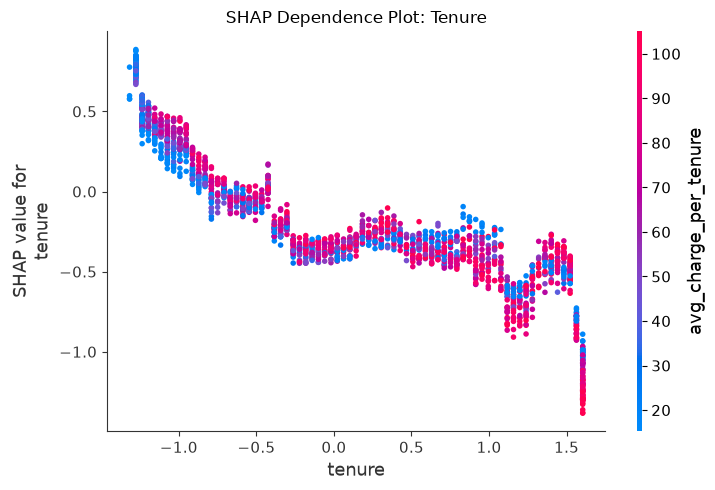

In [33]:
shap.dependence_plot('tenure', shap_values, X_test, show=False)
plt.title('SHAP Dependence Plot: Tenure')
plt.tight_layout()
plt.show()

### Insights

**Global feature importance (SHAP):**
1. Contract_Two year (mean |SHAP| = 0.534)
2. tenure (mean |SHAP| = 0.419)
3. InternetService_Fiber optic (mean |SHAP| = 0.257)

**Validation against manual EDA:**
- SHAP ranking largely confirms the manual EDA findings: contract type, tenure were already flagged as the strongest churn drivers in categorical analysis.
- One notable shift: contract type (both One year and Two year) ranks above payment method in SHAP importance, whereas the Day 2 correlation table showed Electronic check as the single strongest categorical signal (45.3% churn rate). This suggests contract type has more consistent influence across the full customer base, while Electronic check's effect, though large in isolated group comparison, contributes less on average once combined with other features.
- The engineered feature avg_charge_per_tenure (Day 6.5) ranks moderately (0.107), well below the original raw features it was derived from, consistent with the earlier finding that feature engineering added limited new signal.

**Individual prediction examples:**
- High-risk customer (index 445): churn probability = 0.954, driven primarily by Electronic check payment method, Fiber optic internet service, high monthly charges, and the absence of a One-year or Two-year contract.
- Low-risk customer (index 1910): churn probability = 0.013, driven primarily by having a Two-year contract, high tenure, low monthly charges, and no internet service.

**Business interpretation:**
SHAP confirms the model's decisions are grounded in interpretable, business-relevant factors rather than spurious correlations, which supports using this model for customer-facing retention decisions. Contract type and tenure stand out as the strongest levers, reinforcing the earlier recommendation to incentivize long-term contracts as a primary retention strategy.

### Save SHAP Values for Dashboard

In [34]:
shap_data = {
    'shap_values': shap_values,
    'expected_value': explainer.expected_value,
    'feature_names': X_test.columns.tolist()
}

with open('../models/final/shap_data.pkl', 'wb') as f:
    pickle.dump(shap_data, f)

with open('../models/final/xgb_explainer_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

## Model Finalization

### Cross-Validate Final Model

In [35]:
from sklearn.model_selection import cross_val_score

print("CROSS-VALIDATION: FINAL MODEL (Stacking Ensemble)")
print("=" * 60)

cv_scores = cross_val_score(
    stacking_ensemble, X_train, y_train,
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)

print(f"CV ROC-AUC scores: {np.round(cv_scores, 3)}")
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Std: {cv_scores.std():.3f}")
print(f"\nTest set ROC-AUC: {metrics_stacking['roc_auc']:.3f}")
print("Consistent with CV mean" if abs(cv_scores.mean() - metrics_stacking['roc_auc']) < 0.02 else "Check for discrepancy")

CROSS-VALIDATION: FINAL MODEL (Stacking Ensemble)
CV ROC-AUC scores: [0.839 0.862 0.839 0.847 0.859]
Mean: 0.849
Std: 0.010

Test set ROC-AUC: 0.849
Consistent with CV mean


### Reload Model from Pickle

In [36]:
print("SANITY CHECK: RELOAD MODEL FROM DISK")
print("=" * 60)

with open('../models/final/final_model.pkl', 'rb') as f:
    reloaded_model = pickle.load(f)

reloaded_proba = reloaded_model.predict_proba(X_test)[:, 1]
reloaded_auc = roc_auc_score(y_test, reloaded_proba)

print(f"Original ROC-AUC: {metrics_stacking['roc_auc']:.3f}")
print(f"Reloaded model ROC-AUC: {reloaded_auc:.3f}")
print("Match confirmed" if abs(reloaded_auc - metrics_stacking['roc_auc']) < 0.001 else "MISMATCH - investigate")

SANITY CHECK: RELOAD MODEL FROM DISK
Original ROC-AUC: 0.849
Reloaded model ROC-AUC: 0.849
Match confirmed


### Build Model Card

In [37]:
import json
from datetime import datetime

model_card = {
    "model_name": "Customer Churn Stacking Ensemble",
    "created_date": datetime.now().strftime("%Y-%m-%d"),
    "model_type": "StackingClassifier (LogisticRegression + XGBoost + RandomForest, meta-learner: LogisticRegression)",
    "dataset": "Telco Customer Churn (Kaggle)",
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "num_features": int(X_train.shape[1]),
    "performance": {
        "roc_auc_test": round(float(metrics_stacking['roc_auc']), 3),
        "roc_auc_cv_mean": round(float(cv_scores.mean()), 3),
        "roc_auc_cv_std": round(float(cv_scores.std()), 3),
        "accuracy": round(float(metrics_stacking['accuracy']), 3),
        "precision": round(float(metrics_stacking['precision']), 3),
        "recall": round(float(metrics_stacking['recall']), 3),
        "f1": round(float(metrics_stacking['f1']), 3)
    },
    "top_features_shap": mean_abs_shap.head(5)['feature'].tolist(),
    "known_limitations": [
        "Random Forest base learner shows overfitting tendency (train-test gap 0.084) even after tuning",
        "Class imbalance handled via class weights; precision remains moderate (~0.52) due to recall-prioritized threshold",
        "SHAP explainability computed on XGBoost base learner as a proxy, not directly on the stacking ensemble, due to TreeExplainer limitations with meta-estimators",
        "Engineered features (avg_charge_per_tenure, total_services, high_risk_combo) provided minimal performance gain over base features"
    ]
}

with open('../models/final/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Model card saved:")
print(json.dumps(model_card, indent=2))

Model card saved:
{
  "model_name": "Customer Churn Stacking Ensemble",
  "created_date": "2026-09-13",
  "model_type": "StackingClassifier (LogisticRegression + XGBoost + RandomForest, meta-learner: LogisticRegression)",
  "dataset": "Telco Customer Churn (Kaggle)",
  "train_size": 4930,
  "test_size": 2113,
  "num_features": 33,
  "performance": {
    "roc_auc_test": 0.849,
    "roc_auc_cv_mean": 0.849,
    "roc_auc_cv_std": 0.01,
    "accuracy": 0.754,
    "precision": 0.524,
    "recall": 0.807,
    "f1": 0.636
  },
  "top_features_shap": [
    "Contract_Two year",
    "tenure",
    "InternetService_Fiber optic",
    "Contract_One year",
    "MonthlyCharges"
  ],
  "known_limitations": [
    "Random Forest base learner shows overfitting tendency (train-test gap 0.084) even after tuning",
    "Class imbalance handled via class weights; precision remains moderate (~0.52) due to recall-prioritized threshold",
    "SHAP explainability computed on XGBoost base learner as a proxy, not di